In [ ]:
# Brightcart Customer Conversion Prediction

## Project Overview

This project develops a machine learning classification model to predict whether a website visitor will convert to a purchase.

### Business Objective

Help Brightcart's marketing team identify customers who are more likely to convert, so that retargeting efforts and advertising budgets can be prioritized more effectively.

### Approach

- Combine customer, session, marketing, and conversion data using `customer_id`
- Clean missing, invalid, and duplicate data
- Create customer-level session and marketing features
- Encode categorical variables using one-hot encoding
- Apply Min-Max normalization to numerical features
- Compare multiple classification algorithms
- Evaluate models using Accuracy, Precision, Recall, F1-score, and a confusion matrix
- Select the best-performing model
- Generate conversion predictions for the required customers

### Final Model

**Tuned AdaBoost**

- Accuracy: **77.33%**
- Precision: **69.57%**
- Recall: **61.54%**
- F1-score: **65.31%**

### Target Variable

`converted` — **Yes / No**

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import random

In [2]:
# Show all rows
pd.set_option('display.max_rows', None)

# Show all columns
pd.set_option('display.max_columns', None)

In [3]:
# Load .csv files to data frames

customer_df = pd.read_csv("customer_master.csv")
session_df  = pd.read_csv("session_logs.csv")
marketing_df = pd.read_csv("marketing_touchpoints.csv")
label_df = pd.read_csv("converted_labeled.csv")
predict_df = pd.read_csv("converted_to_predict.csv")

In [4]:
print(customer_df.shape)
#print(customer_df.info())

print(session_df.shape)
#print(session_df.info())

print(marketing_df.shape)
#print(marketing_df.info())

print(label_df.shape)
#print(label_df.info())

print(predict_df.shape)
#print(predict_df.info())

# Target distribution: count and percentage
target_distribution = label_df['converted'].value_counts()
target_percentage = label_df['converted'].value_counts(normalize=True) * 100

distribution_df = pd.DataFrame({
    'Count': target_distribution,
    'Percentage': target_percentage.round(2)
})

display(distribution_df)

(437, 5)
(4049, 5)
(1835, 5)
(372, 2)
(65, 1)


,Count,Percentage
converted,,
No,241,64.78
Yes,131,35.22


In [5]:
#Inner join customer data and available labels to get only training customers
training_df = customer_df.merge(label_df,on="customer_id",how="inner")
 
print(training_df.isnull().sum())

#Replace NaN with 'Unknown'
training_df["region"] = training_df["region"].fillna("Unknown")
training_df["referral_source"] = training_df["referral_source"].fillna("Unknown")

customer_id                0
account_type               0
region                   100
referral_source           20
days_since_last_visit      0
converted                  0
dtype: int64


In [6]:

#Session records are primarily a data quality (technical) issue, not a customer behavior issue.
session_df = session_df.drop(columns = ['record_id'])

#Negative pages_viewed is impossible in the real world, so it is invalid data.replace with NaN for now, later imputate
session_df.loc[session_df["pages_viewed"] < 0, "pages_viewed"] = pd.NA

#Remove Duplicates ,not real additional sessions.
session_df = session_df.drop_duplicates()

# Impute missing pages_viewed with the global median
session_df["pages_viewed"] = session_df["pages_viewed"].fillna(
    session_df["pages_viewed"].median()
)

# Aggregate so we can take customer specific session/browsing behaviour and merge with training df
session_agg_df = (
    session_df
    .groupby("customer_id")
    .agg(
        total_sessions=("customer_id", "count"),
        total_pages_viewed=("pages_viewed", "sum"),
        avg_pages_viewed=("pages_viewed", "mean"),
        max_pages_viewed=("pages_viewed", "max"),
        total_bounces=("bounce_flag", "sum"),  # True = 1 False  = 0 for aggregation
        bounce_rate=("bounce_flag", "mean")    # True = 1 False  = 0 for aggregation
    )
    .reset_index()
)

#Merge training with session agg on left join 
training_df = training_df.merge(
    session_agg_df,
    on="customer_id",
    how="left"
)

In [7]:
#Prepare and aggregate marketing data

marketing_df["response_time_hours"] = marketing_df["response_time_hours"].fillna(
    marketing_df["response_time_hours"].median()
)

#Unique Records id are not related a customer behavior.
marketing_df = marketing_df.drop(columns=["record_id"])

# Aggregate so we can take customer specific marketing response/behaviour and merge with training df
marketing_agg_df = (
    marketing_df
    .groupby("customer_id")
    .agg(
        total_touchpoints=("customer_id", "count"),
        avg_response_time=("response_time_hours", "mean"),
        min_response_time=("response_time_hours", "min"),
        max_response_time=("response_time_hours", "max")
    )
    .reset_index()   #reset index as default not customer_id
)

channel_counts = pd.crosstab(   # Extract behaviour info regarding how many times each customer interacted with each marketing channel
    marketing_df["customer_id"],
    marketing_df["channel"]
).reset_index()


marketing_agg_df = marketing_agg_df.merge(  #Left join extracted channel count with marketing aggregate table 
    channel_counts,
    on="customer_id",
    how="left"
)

training_df = training_df.merge(  #merge training customers with marketing data 
    marketing_agg_df,
    on="customer_id",
    how="left"
)

count_columns = [          #to replace touchpoints and others with 0 instead of NaN as these customers has no interaction count
    "total_touchpoints",
    "Email",
    "Push Notification",
    "Retarget Ad",
    "SMS"
]
training_df[count_columns] = training_df[count_columns].fillna(0)

#Add a feature flag for those with no market touchpoints 1 -  no mark touch , 0 - atleast 1 touch
training_df["no_marketing"] = training_df["total_touchpoints"].eq(0).astype(int)

# fill with global median for response times for those with NaN
response_columns = [
    "avg_response_time",
    "min_response_time",
    "max_response_time"
]

for col in response_columns:
    training_df[col] = training_df[col].fillna(training_df[col].median())
    

training_df.describe()

pd.DataFrame({  # verify all coloumns dtype
    "Column": training_df.columns,
    "dtype": training_df.dtypes.astype(str)
})

,Column,dtype
customer_id,customer_id,str
account_type,account_type,str
region,region,str
referral_source,referral_source,str
days_since_last_visit,days_since_last_visit,int64
converted,converted,str
total_sessions,total_sessions,int64
total_pages_viewed,total_pages_viewed,float64
avg_pages_viewed,avg_pages_viewed,float64
max_pages_viewed,max_pages_viewed,float64


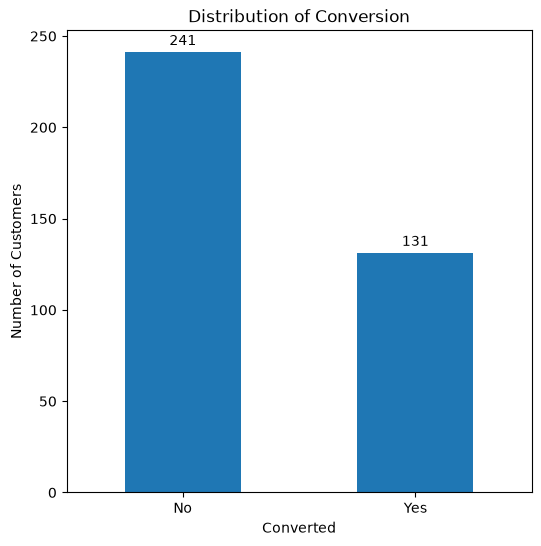

In [8]:
# Analyse Target distribution - Converted
plt.figure(figsize=(6, 6))

ax = training_df["converted"].value_counts().plot(kind="bar")

# Add numbers above bars
ax.bar_label(ax.containers[0], fmt="%d", padding=3)

plt.title("Distribution of Conversion")
plt.xlabel("Converted")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

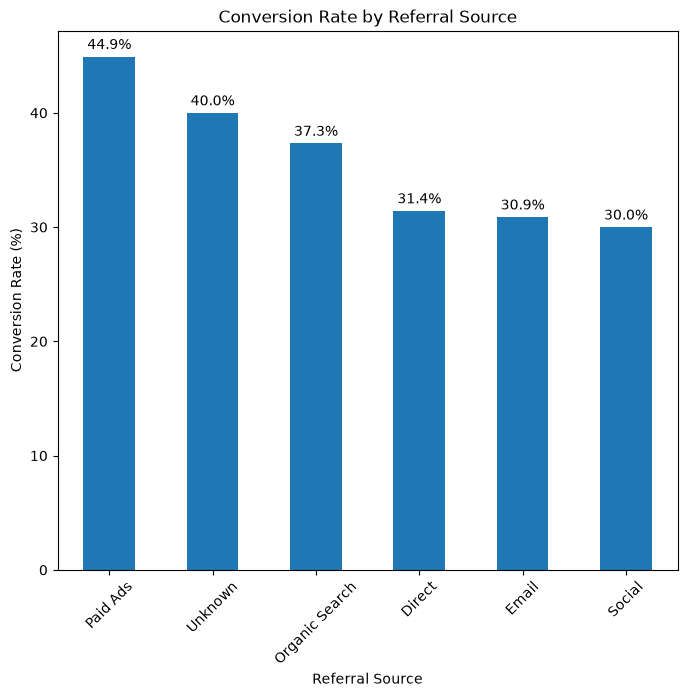

In [9]:
# Conversion rate by referral source
conversion_rate = (
    training_df.groupby("referral_source")["converted"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 7))

ax = conversion_rate.plot(kind="bar")

# Add percentage values above bars
ax.bar_label(
    ax.containers[0],
    fmt="%.1f%%",
    padding=3
)

plt.title("Conversion Rate by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=45)
plt.show()

<Figure size 900x600 with 0 Axes>

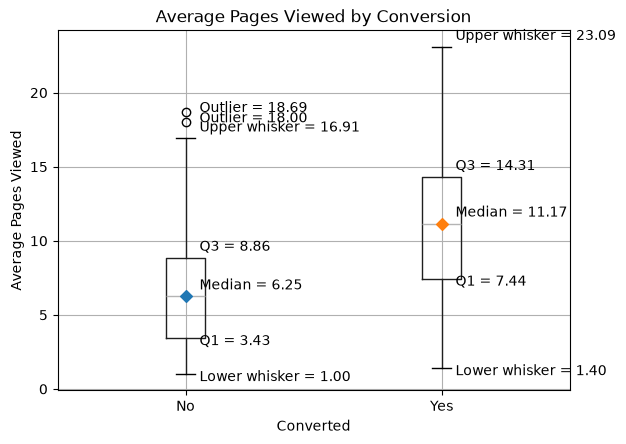

In [10]:
# Average pages viewed vs conversion
plt.figure(figsize=(9, 6))

ax = training_df.boxplot(
    column="avg_pages_viewed",
    by="converted",
    showfliers=True
)

plt.title("Average Pages Viewed by Conversion")
plt.suptitle("")
plt.xlabel("Converted")
plt.ylabel("Average Pages Viewed")

groups = ["No", "Yes"]

for i, group in enumerate(groups, start=1):

    data = training_df.loc[
        training_df["converted"] == group,
        "avg_pages_viewed"
    ].dropna()

    # Quartiles
    q1 = data.quantile(0.25)
    median = data.quantile(0.50)
    q3 = data.quantile(0.75)

    # IQR
    iqr = q3 - q1

    # Whisker boundaries
    lower_boundary = q1 - 1.5 * iqr
    upper_boundary = q3 + 1.5 * iqr

    # Actual whisker limits
    lower_whisker = data[data >= lower_boundary].min()
    upper_whisker = data[data <= upper_boundary].max()

    # Outliers
    outliers = data[
        (data < lower_boundary) |
        (data > upper_boundary)
    ]

    # Mark median
    plt.scatter(
        i, median,
        marker="D",
        zorder=3
    )

    # Median label
    plt.annotate(
        f"Median = {median:.2f}",
        (i, median),
        xytext=(10, 5),
        textcoords="offset points"
    )

    # Q1 and Q3 labels
    plt.annotate(
        f"Q1 = {q1:.2f}",
        (i, q1),
        xytext=(10, -5),
        textcoords="offset points"
    )

    plt.annotate(
        f"Q3 = {q3:.2f}",
        (i, q3),
        xytext=(10, 5),
        textcoords="offset points"
    )

    # Whisker labels
    plt.annotate(
        f"Lower whisker = {lower_whisker:.2f}",
        (i, lower_whisker),
        xytext=(10, -5),
        textcoords="offset points"
    )

    plt.annotate(
        f"Upper whisker = {upper_whisker:.2f}",
        (i, upper_whisker),
        xytext=(10, 5),
        textcoords="offset points"
    )

    # Outlier labels
    for outlier in outliers:
        plt.annotate(
            f"Outlier = {outlier:.2f}",
            (i, outlier),
            xytext=(10, 0),
            textcoords="offset points"
        )

plt.show()


In [11]:
def evaluate_model(model_name, y_test, y_pred):  #For upcoming evaluations for diff models

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label="Yes"),
        "Recall": recall_score(y_test, y_pred, pos_label="Yes"),
        "F1": f1_score(y_test, y_pred, pos_label="Yes"),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

In [12]:
# Split target and prepare
    
X = training_df.drop(columns=["converted"])
y = training_df["converted"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state=42,
    stratify = y  #Because this is classification and we have some class imbalance, use stratify=y so both sets preserve roughly the same Yes/No proportion
)

categorical_columns = [
    "account_type",
    "region",
    "referral_source"
]

numerical_columns = [
    col for col in X.columns
    if col not in categorical_columns and col != "customer_id"
]

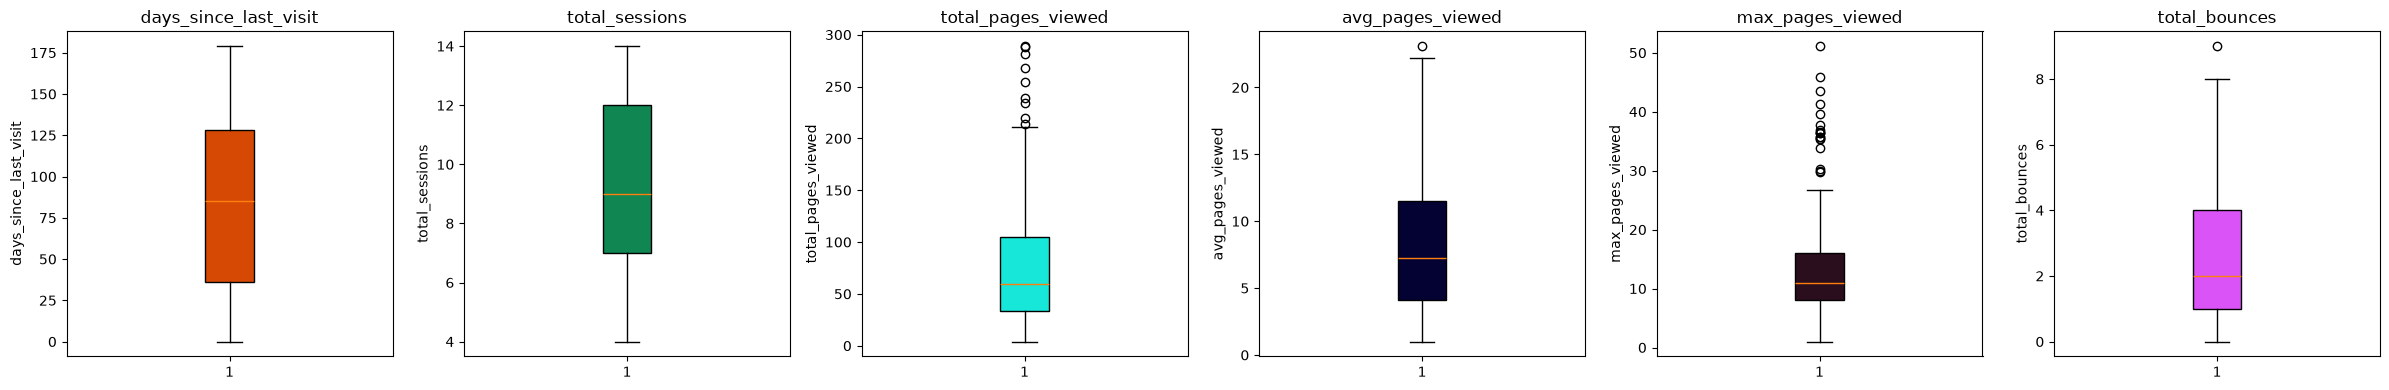

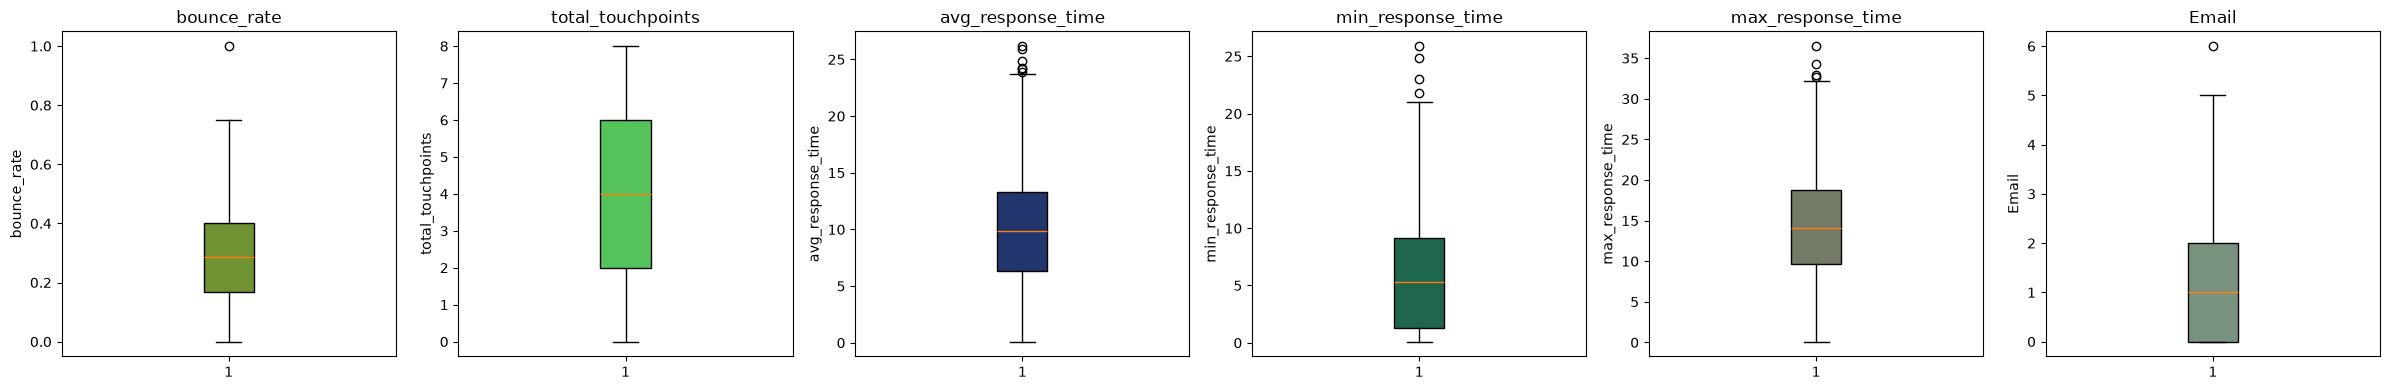

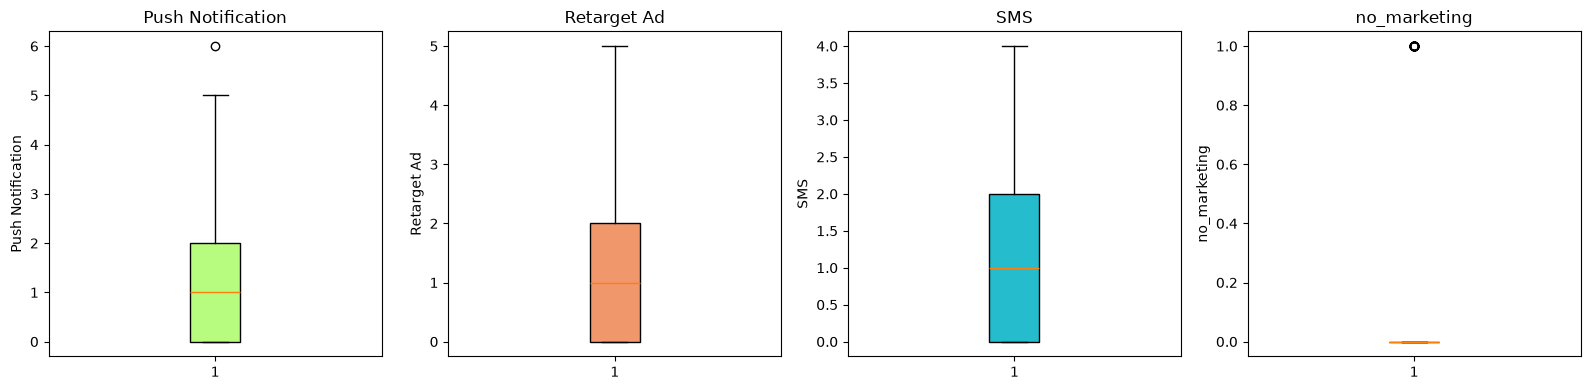

In [13]:
#Box plot check for numerical coloms

n = 6

for i in range(0, len(numerical_columns), n):

    cols = numerical_columns[i:i+n]

    fig, axes = plt.subplots(1, n, figsize=(24, 4))

    for ax, col in zip(axes, cols):

        random_color = (
            random.random(),
            random.random(),
            random.random()
        )

        ax.boxplot(
            X[col].dropna(),
            patch_artist=True,
            boxprops=dict(facecolor=random_color)
        )

        ax.set_title(col)
        ax.set_ylabel(col)

    # Hide unused plots in the last row
    for ax in axes[len(cols):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

In [14]:
# Preprocess , Encode , scale etc
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        ),
        (
            "num",
            MinMaxScaler(),
            numerical_columns
        )
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [15]:
# TRAIN MODELS

#------------ LOGISTIC REGRESSION  -------------#
     
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_processed, y_train)

lr_pred = lr_model.predict(X_test_processed)


#----------- DECISION TREE ------------#
     
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_processed,y_train)
dt_pred = dt_model.predict(X_test_processed)   
     


#-----------  RANDOM FOREST -----------#
     
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf_model.fit(X_train_processed, y_train)
rf_pred = rf_model.predict(X_test_processed)

# feature_names = preprocessor.get_feature_names_out()
# feature_importance = pd.Series(
#     rf_model.feature_importances_,
#     index=feature_names
# ).sort_values(ascending=False)
# feature_importance.head(15)


#-----------  K-Nearest Neighbors ------------#
     
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_processed,y_train)
knn_pred = knn_model.predict(X_test_processed)



#---------- SVM - Support Vector Machine -------------#
   
svm_model = SVC(random_state=42)
svm_model.fit(X_train_processed,y_train)
svm_pred = svm_model.predict(X_test_processed)



#------------  Gradient Boosting Classifier  ------------#

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_processed, y_train)
gb_pred = gb_model.predict(X_test_processed)


#------------  AdaBoost Classifier  ---------------#

ada_model = AdaBoostClassifier(random_state=42)
ada_model.fit(X_train_processed, y_train)
ada_pred = ada_model.predict(X_test_processed)


#--------------- Naive Bayes Classifier  -------------#

nb_model = GaussianNB()
nb_model.fit(X_train_processed, y_train)
nb_pred = nb_model.predict(X_test_processed)


#------ Tuning ---------#

ada_tuned = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.2,
    random_state=42
)

ada_tuned.fit(X_train_processed, y_train)

ada_tuned_pred = ada_tuned.predict(X_test_processed)



#------------------ EVALUATION RESULTS ---------------------#

results = []

results.append(evaluate_model("Logistic Regression", y_test, lr_pred))
results.append(evaluate_model("Decision Tree", y_test, dt_pred))
results.append(evaluate_model("Random Forest", y_test, rf_pred))
results.append(evaluate_model("KNN", y_test, knn_pred))
results.append(evaluate_model("SVM", y_test, svm_pred))
results.append(evaluate_model("Gradient Boosting", y_test, gb_pred))
results.append(evaluate_model("AdaBoost", y_test, ada_pred))
results.append(evaluate_model("Naive Bayes", y_test, nb_pred))
results.append(evaluate_model("AdaBoost Tuned", y_test, ada_tuned_pred))

results_df = pd.DataFrame(results)

results_df = (
    results_df
    .sort_values(by="F1", ascending=False)
    .reset_index(drop=True)
)

display(Markdown("### Evaluation table "))

display(
    results_df.style.format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1": "{:.2%}"
    })
)

display(Markdown("""
### Confusion Matrix

✔️ **TN (True Negative):** Did not convert → correctly predicted No

⚠️ **FP (False Positive):** Did not convert → predicted Yes

🚨 **FN (False Negative):** Converted → predicted No (**missed conversion**)

✔️ **TP (True Positive):** Converted → correctly predicted Yes
"""))



### Evaluation table 

,Model,Accuracy,Precision,Recall,F1,TN,FP,FN,TP
0,AdaBoost Tuned,77.33%,69.57%,61.54%,65.31%,42,7,10,16
1,AdaBoost,74.67%,62.96%,65.38%,64.15%,39,10,9,17
2,Random Forest,73.33%,60.71%,65.38%,62.96%,38,11,9,17
3,Gradient Boosting,70.67%,57.69%,57.69%,57.69%,38,11,11,15
4,Decision Tree,66.67%,51.72%,57.69%,54.55%,35,14,11,15
5,Naive Bayes,68.00%,53.85%,53.85%,53.85%,37,12,12,14
6,Logistic Regression,68.00%,54.17%,50.00%,52.00%,38,11,13,13
7,SVM,66.67%,53.33%,30.77%,39.02%,42,7,18,8
8,KNN,57.33%,28.57%,15.38%,20.00%,39,10,22,4



### Confusion Matrix

✔️ **TN (True Negative):** Did not convert → correctly predicted No

⚠️ **FP (False Positive):** Did not convert → predicted Yes

🚨 **FN (False Negative):** Converted → predicted No (**missed conversion**)

✔️ **TP (True Positive):** Converted → correctly predicted Yes


In [16]:
# ------- FINAL PREDICTION — data preparation ------#

predict_df = pd.read_csv('converted_to_predict.csv') # load customer_ids to predict using trained models

# Merge with customer master data
prediction_df = customer_df.merge(
    predict_df,
    on="customer_id",
    how="inner"
)

# add customer  session aggregates
prediction_df = prediction_df.merge(
    session_agg_df,
    on="customer_id",
    how="left"
)

# add existing marketing features
prediction_df = prediction_df.merge(
    marketing_agg_df,
    on="customer_id",
    how="left"
)

prediction_df[count_columns] = prediction_df[count_columns].fillna(0)

# Customers with no marketing interaction 
prediction_df["no_marketing"] = (
    prediction_df["total_touchpoints"].eq(0).astype(int)
)

for col in response_columns:
    prediction_df[col] = prediction_df[col].fillna(
        training_df[col].median()
    )
    
prediction_df["region"] = prediction_df["region"].fillna("Unknown")
prediction_df["referral_source"] = prediction_df["referral_source"].fillna("Unknown")    

In [17]:
X_predict = prediction_df.drop(columns=["customer_id"])
X_predict_processed = preprocessor.transform(X_predict)

predictions = ada_tuned.predict(X_predict_processed)

In [18]:
# Checking feature importance 

feature_names = preprocessor.get_feature_names_out()

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": ada_tuned.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

display(
    feature_importance_df[
        feature_importance_df["Importance"] > 0
    ].style.format({"Importance": "{:.2%}"})
)

,Feature,Importance
0,num__avg_pages_viewed,73.69%
1,num__max_response_time,18.45%
2,num__total_pages_viewed,4.63%
3,num__min_response_time,3.22%


In [19]:

# Final predictions for the 65 customers using AdaBoost Tuned

final_predictions_df = prediction_df.copy()

final_predictions_df.insert(
    1,
    "predicted_converted",
    predictions
)

final_predictions_df = final_predictions_df.sort_values(
    by="predicted_converted",
    ascending=False
).reset_index(drop=True)

display(Markdown("### PREDICTIONS "))

#display(final_predictions_df)  #For cross verification

display(final_predictions_df[['customer_id','predicted_converted']])

### PREDICTIONS 

,customer_id,predicted_converted
0,VIS-0001,Yes
1,VIS-0122,Yes
2,VIS-0415,Yes
3,VIS-0398,Yes
4,VIS-0328,Yes
5,VIS-0321,Yes
6,VIS-0314,Yes
7,VIS-0253,Yes
8,VIS-0248,Yes
9,VIS-0228,Yes
